2025-12-12 18:43:35,639 [WARNING] Duplicated values found in preranked stats: 93.75% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Skipping tvae_1: could not read ../DGE/DGE_Nivo/Seed_1/DGE_tvae_1.csv: [Errno 2] No such file or directory: '../DGE/DGE_Nivo/Seed_1/DGE_tvae_1.csv'
----GSEA Origin----


2025-12-12 18:44:06,575 [WARNING] Duplicated values found in preranked stats: 93.83% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----GSEA avatarsk5_1----


2025-12-12 18:44:37,604 [WARNING] Duplicated values found in preranked stats: 94.96% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

----GSEA gaussiancopula_1----


2025-12-12 18:46:10,405 [WARNING] Duplicated values found in preranked stats: 94.38% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----GSEA gaussiancopulaDebug_1----


2025-12-12 18:46:41,607 [WARNING] Duplicated values found in preranked stats: 92.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


----GSEA synthpop_1----


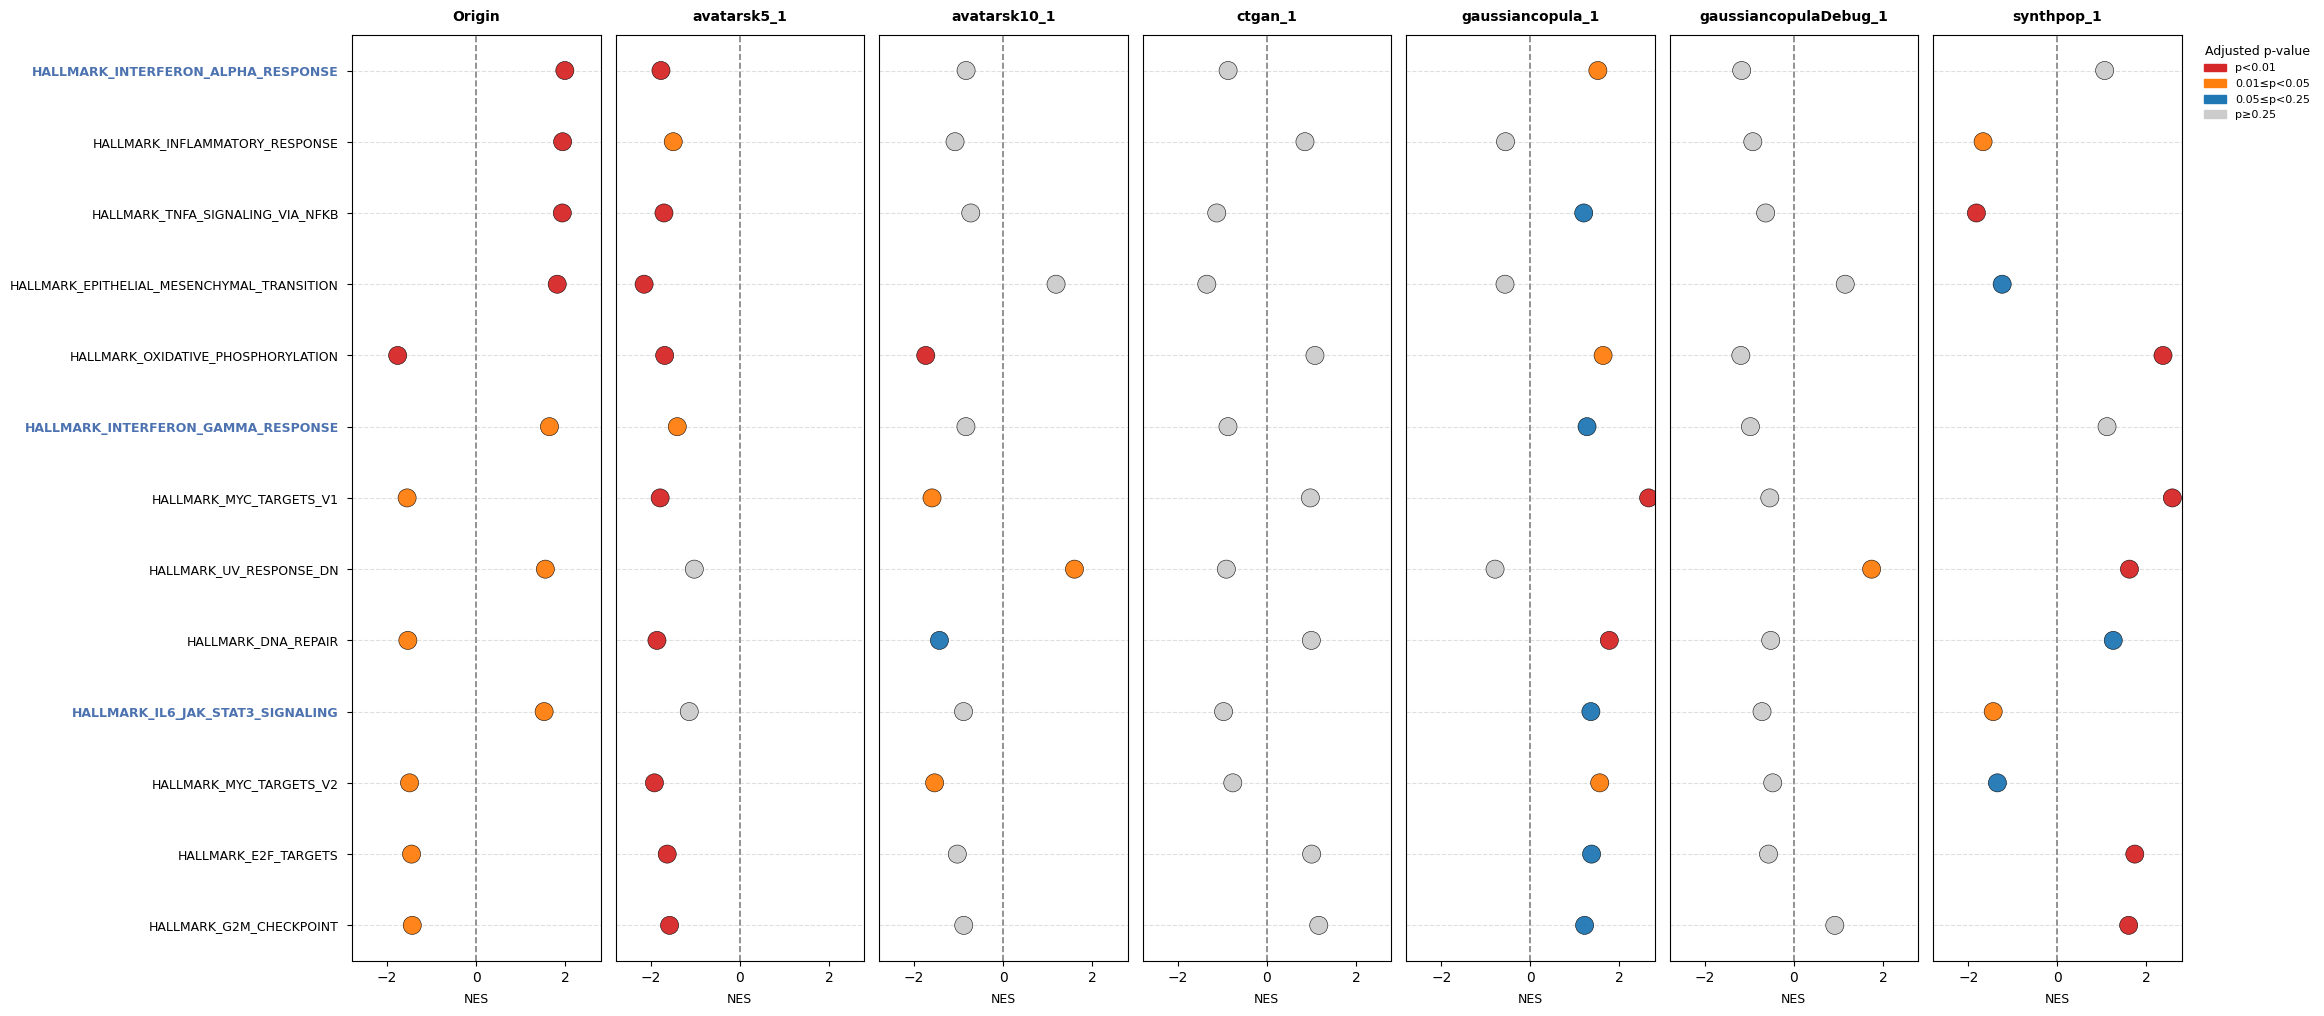

In [2]:
import pandas as pd
import numpy as np
import os
import gseapy as gp
from Utils import compute_jaccard_indices, extract_significances, spearman_across_datasets
from GSEA import plot_pathway

seeds = [1]

# Load origin DGE once (used for every seed)
original_dge = pd.read_csv('../DGE/DGE_Nivo/DGE_Origin.csv')

# Helper: safe status filtering (tolerant to missing Status column)
def get_safe_df(df, status_col='Status'):
    """
    Small internal helper (script-local): return rows with status=='ok' if the status column exists,
    otherwise return a shallow copy of the dataframe.
    """
    if status_col in df.columns:
        return df[df[status_col] == 'ok'].copy()
    return df.copy()


for seed in seeds:
    # Build dges_results per-seed (do NOT accumulate across seeds)
    dges_results = {}
    dges_results['Origin'] = original_dge.copy()

    synthetic_datasets = [
        f"avatarsk5_{seed}",
        f"avatarsk10_{seed}",
        f"ctgan_{seed}",
        f"gaussiancopula_{seed}",
        f"synthpop_{seed}",
        f"tvae_{seed}",
    ]

    # Load synthetic DGE results for this seed (skip missing files)
    for synthetic_dataset in synthetic_datasets:
        path = f'../DGE/DGE_Nivo/Seed_{seed}/DGE_{synthetic_dataset}.csv'
        try:
            dge_syn_result = pd.read_csv(path)
            dges_results[synthetic_dataset] = dge_syn_result
        except Exception as err:
            print(f"Skipping {synthetic_dataset}: could not read {path}: {err}")

    # Prepare output dir
    os.makedirs(f'Seed_{seed}', exist_ok=True)

    # GSEA
    hallmarks_gmt = "h.all.v2025.1.Hs.symbols.gmt"
    GSEA_overall = {}

    for name, degs in dges_results.items():
        print(f"----GSEA {name}----")

        # get safe dataframe (allow for missing Status column)
        safe_df = get_safe_df(degs)

        # Ensure required columns exist
        if 'Gene' not in safe_df.columns or ('Log2FC' not in safe_df.columns and 'log2FoldChange' not in safe_df.columns):
            print(f"Skipping {name}: missing required columns 'Gene' or LFC column.")
            continue

        # Prepare rank score safely: coerce numeric and clip P-values to avoid -inf
        # Prefer 'P_value' but fall back to common alternatives if missing
        p_candidates = ['P_value', 'p_value', 'pvalue', 'p.val', 'pval']
        p_col = next((c for c in p_candidates if c in safe_df.columns), None)
        if p_col is None:
            print(f"Skipping {name}: no p-value column found among {p_candidates}.")
            continue

        # Make sure we have a consistent LFC column name
        lfc_candidates = ['Log2FC', 'log2FoldChange', 'logFC', 'LFC']
        lfc_col = next((c for c in lfc_candidates if c in safe_df.columns), None)
        if lfc_col is None:
            print(f"Skipping {name}: no LFC column found among {lfc_candidates}.")
            continue

        # Compute Rank_Score robustly
        p_numeric = pd.to_numeric(safe_df[p_col], errors='coerce').clip(lower=np.nextafter(0, 1))
        lfc_numeric = pd.to_numeric(safe_df[lfc_col], errors='coerce').fillna(0.0)
        safe_df = safe_df.assign(Rank_Score=np.sign(lfc_numeric) * (-np.log10(p_numeric)))

        # Remove rows with NaN Rank_Score (cannot rank)
        ranked_results_df = safe_df.dropna(subset=['Rank_Score'])
        if ranked_results_df.empty:
            print(f"Skipping {name}: no valid Rank_Score values to run prerank.")
            continue

        # Build rnk DataFrame as required by gseapy (index: gene, column: score)
        rnk = ranked_results_df[['Gene', 'Rank_Score']].set_index('Gene').sort_values('Rank_Score', ascending=False)

        # Run prerank with error handling
        try:
            pre_res = gp.prerank(
                rnk=rnk,
                gene_sets=hallmarks_gmt,
                threads=4,  # reduce threads to sensible default; change if you have many cores
                permutation_num=10000,  # production value; reduce for debugging
                outdir=None,
                seed=seed,
                verbose=False,
            )
        except Exception as err:
            print(f"GSEA prerank failed for {name}: {err}")
            continue

        # res2d is typically a DataFrame with terms as index; convert index to a 'Term' column
        prerank_overall = pre_res.res2d.reset_index()
        # Ensure first column is named 'Term' (index name may be None)
        if 'Term' not in prerank_overall.columns:
            prerank_overall.rename(columns={prerank_overall.columns[0]: 'Term'}, inplace=True)

        # Create common aliases expected downstream: 'FDR q-val' and 'NES' if possible
        if 'fdr' in prerank_overall.columns and 'FDR q-val' not in prerank_overall.columns:
            prerank_overall['FDR q-val'] = prerank_overall['fdr']
        if 'fdr q-val' in prerank_overall.columns and 'FDR q-val' not in prerank_overall.columns:
            prerank_overall['FDR q-val'] = prerank_overall['fdr q-val']
        if 'nes' in prerank_overall.columns and 'NES' not in prerank_overall.columns:
            prerank_overall['NES'] = prerank_overall['nes']

        # write CSV for record (keep Term column)
        try:
            prerank_overall.to_csv(f"Seed_{seed}/GSEA_{name}.csv", index=False)
        except Exception as err:
            print(f"Warning: could not write GSEA result for {name}: {err}")

        GSEA_overall[name] = prerank_overall

    # If Origin GSEA missing, skip downstream comparisons for this seed
    if "Origin" not in GSEA_overall:
        print(f"Seed {seed}: Origin GSEA missing, skipping Jaccard/Spearman/plots for this seed.")
        continue

    # Calculate Jaccard Index
    orig_paths = extract_significances(
        GSEA_overall["Origin"],
        term_col="Term",
        adj_p_col="FDR q-val",
        threshold=0.05,
    )
    synth_paths_dict = {
        k: extract_significances(v, term_col="Term", adj_p_col="FDR q-val", threshold=0.05)
        for k, v in GSEA_overall.items() if k != "Origin"
    }
    jaccard_df = compute_jaccard_indices(orig_paths, synth_paths_dict)
    # jaccard_df.to_csv(f"Seed_{seed}/JaccardIndex_GSEA.csv", index=False)

    # Subset each dataset to terms present in origin significant set for paired spearman (as in original snippet)
    GSEA_Sig = {}
    for data, dfgsea in GSEA_overall.items():
        dfgsea_sig = dfgsea[dfgsea['Term'].isin(orig_paths)].copy()
        GSEA_Sig[data] = dfgsea_sig

    # Calculate Spearman correlations across datasets
    spearman_df, _ = spearman_across_datasets(
        gsea_overall=GSEA_Sig,
        origin="Origin",
        term_col="Term",
        score_col="NES",
        min_terms=3,
    )
    # spearman_df.to_csv(f"Seed_{seed}/Spearman_GSEA.csv", index=False)

    # Prepare plotting reference and highlights (use the origin significant pathways)
    ref_pathway_list = orig_paths
    highlight_pathways = [
        'HALLMARK_IL6_JAK_STAT3_SIGNALING',
        'HALLMARK_INTERFERON_ALPHA_RESPONSE',
        'HALLMARK_INTERFERON_GAMMA_RESPONSE',
    ]

    # Call the plotting function (pass column names that plot_pathway expects)
    try:
        fig, df_used = plot_pathway(
            ssGSEA_comparison=GSEA_Sig,
            ref_pathway_list=ref_pathway_list,
            highlight_pathways=highlight_pathways,
            origin_name="Origin",
            term_col="Term",
            pval_col="FDR q-val",
            diff_col="NES",
            show=True,
            save_path=None,
        )
    except Exception as err:
        print(f"Plotting failed for seed {seed}: {err}")

In [1]:
import pandas as pd
import numpy as np
import os
import gseapy as gp
from Utils import compute_jaccard_indices, extract_significances, spearman_across_datasets
from GSEA import plot_pathway

seeds = [1]

# Load origin DGE once (used for every seed)
original_dge = pd.read_csv('../DGE/DGE_Nivo/DGE_Origin.csv')

# Helper: safe status filtering (tolerant to missing Status column)
def get_safe_df(df, status_col='Status'):
    """
    Small internal helper (script-local): return rows with status=='ok' if the status column exists,
    otherwise return a shallow copy of the dataframe.
    """
    if status_col in df.columns:
        return df[df[status_col] == 'ok'].copy()
    return df.copy()


for seed in seeds:
    # Build dges_results per-seed (do NOT accumulate across seeds)
    dges_results = {}
    dges_results['Origin'] = original_dge.copy()

    synthetic_datasets = [
        f"avatarsk5_{seed}",
        f"avatarsk10_{seed}",
        f"ctgan_{seed}",
        f"gaussiancopula_{seed}",
        f"synthpop_{seed}",
        f"tvae_{seed}",
    ]

    # Load synthetic DGE results for this seed (skip missing files)
    for synthetic_dataset in synthetic_datasets:
        path = f'../DGE/DGE_Nivo/Seed_{seed}/DGE_{synthetic_dataset}.csv'
        try:
            dge_syn_result = pd.read_csv(path)
            dges_results[synthetic_dataset] = dge_syn_result
        except Exception as err:
            print(f"Skipping {synthetic_dataset}: could not read {path}: {err}")

Skipping tvae_1: could not read ../DGE/DGE_Nivo/Seed_1/DGE_tvae_1.csv: [Errno 2] No such file or directory: '../DGE/DGE_Nivo/Seed_1/DGE_tvae_1.csv'


In [6]:
len(dges_results['Origin']['P_value'].unique())

1149

In [4]:
spearman_df

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_1,0.741758,0.003701,13
1,avatarsk5_1,0.203297,0.505315,13
2,ctgan_1,-0.615385,0.025167,13
3,gaussiancopulaDebug_1,-0.142857,0.641516,13
4,gaussiancopula_1,-0.692308,0.008730,13
5,synthpop_1,-0.675824,0.011225,13
